<a href="https://colab.research.google.com/github/vdlucas-queiroz/CadImobi/blob/main/COTIA_prompt_coord.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# RECONSTRUÇÃO DE GEOMETRIA DE MEMORIAL DESCRITIVO POR MEIO DE COORDENADAS
# Vinicius D'Lucas Bezerra e Queiroz

In [ ]:
!pip install adjustText
!pip install simplekml
!pip install folium pyproj
!pip cache purge
!pip install -U google-genai


Files removed: 12


In [ ]:
import pandas as pd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from adjustText import adjust_text
import folium
from pyproj import Transformer

from google.colab import files
from google import genai
from google.colab import userdata
import re
import time
import json


In [ ]:
# 1. Configuração da API
try:
    api_key = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=api_key)
    print("API Configurada com sucesso!")
except Exception as e:
    print("ERRO: Configure o Secret 'GEMINI_API_KEY' no menu lateral.")

def obter_tabela_via_ai(caminho_arquivo, prompt):
    """
    Envia o arquivo (PDF ou Imagem) diretamente para o Gemini.
    A IA faz o OCR (leitura de imagem) e a extração dos dados em um único passo.
    """

    # Busca o nome correto do modelo disponívelA
    nome_modelo = 'gemini-2.5-flash' # Versão estável e rápida

    # 2. Upload do arquivo para a API do Google (suporta PDF e Imagens)
    print(f"Fazendo upload do arquivo: {caminho_arquivo}...")
    sample_file = client.files.upload(file=caminho_arquivo)

    # Aguarda o processamento do arquivo pelo Google
    while sample_file.state.name == "PROCESSING":
        print(".", end="")
        time.sleep(2)
        sample_file = client.files.get(name=sample_file.name)

    # 3. Prompt especializado (ajustado para ler páginas 3 a 7) #AJUSTAR O PROMPT

    print("Gemini analisando o documento (OCR + Extração)...")
    response = client.models.generate_content(
        model=nome_modelo,
        contents=[sample_file, prompt],
        config={
            "response_mime_type": "application/json"
        }
    )

  # 4. Limpeza (opcional, mas boa prática)
    client.files.delete(name=sample_file.name)

    return response.text


API Configurada com sucesso!


In [ ]:
# Funções

# Conversão de gms para decimal

def gms_to_decimal(az):
    g, rest = az.split("°")
    m, s = rest.replace('"','').split("'")
    return float(g) + float(m)/60 + float(s)/3600


# Teste de rotação de coordenadas

def rotate_coords(coords, theta, pivot):
    coords = np.array(coords, dtype=float)
    x0, y0 = pivot

    translated = coords - np.array([x0, y0])

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    rotated = translated @ R.T
    return rotated + np.array([x0, y0])

  # PLOTAGEM OS RESULTADOS COM MAPA BASE

def plot_vertices_folium(
    coords,
    epsg_utm="EPSG:31983",
    zoom_start=18
):
    """
    Plota vértices e polígono em um mapa Folium.
    """

    from pyproj import Transformer
    import folium

    # Transformador UTM -> WGS84
    transformer = Transformer.from_crs(
        epsg_utm,
        "EPSG:4326",
        always_xy=True
    )

    # Conversão das coordenadas
    coords_geo = [transformer.transform(x, y) for x, y in coords]

    # Centro do mapa
    lon_c = sum(pt[0] for pt in coords_geo) / len(coords_geo)
    lat_c = sum(pt[1] for pt in coords_geo) / len(coords_geo)

    m = folium.Map(
        location=[lat_c, lon_c],
        zoom_start=zoom_start,
        tiles="OpenStreetMap"
    )

    # Polígono (AMARELO)
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in coords_geo],
        color="yellow",
        weight=2,
        fill=True,
        fill_color="yellow",
        fill_opacity=0.3,
        tooltip="Polígono reconstruído"
    ).add_to(m)

    # Vértices (PONTOS BRANCOS)
    for i, ((x, y), (lon, lat)) in enumerate(zip(coords, coords_geo)):
        nome = f"P{i+1:02d}"

        # Destaque do ponto inicial
        radius = 7 if i == 0 else 5

        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color="white",
            fill=True,
            fill_color="white",
            fill_opacity=1,
            popup=(
                f"<b>{nome}</b><br>"
                f"UTM 23S (SIRGAS2000)<br>"
                f"X = {x:.3f} m<br>"
                f"Y = {y:.3f} m"
            )
        ).add_to(m)

        # Rótulo fixo (FONTE BRANCA)
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(
                html=f"""
                <div style="
                    font-size:10px;
                    font-weight:bold;
                    color:white;
                    text-shadow: 1px 1px 2px black;
                    transform: translate(6px, -6px);
                ">
                    {nome}
                </div>
                """
            )
        ).add_to(m)

    # Camada de imagem de satélite
    folium.TileLayer(
        "Esri.WorldImagery",
        name="Imagem de Satélite (ESRI)",
        control=True
    ).add_to(m)

    folium.LayerControl().add_to(m)

    return m




1. EXTRAÇÃO DE AZIMUTE E DISTÂNCIA EM TEXTO

In [ ]:
prompt = """
Você é um especialista em georreferenciamento de imoveis e topografia.
Analise as páginas do arquivo.

Extraia todas coordenadas os pontos (Ponto, Coordenada Este e Coorenada Norte) do memorial descritivo.
Mesmo que o documento seja uma imagem digitalizada, faça o OCR e extraia os dados na forma a seguir:

[
  {"Ponto": "01", "E": 300000.000, "N": 7000000.000},
  {"Ponto": "02", "E": 300000.000 , "N": 7000000.000}
]



Regras:
1. Retorne APENAS o código da lista, nada de explicações ou Markdown.
2. O tipo do dado da coordenada é float.
3. Não pule nenhum vértice. Verifique do ponto 01 até o fechamento.
"""

In [ ]:
# --- EXECUÇÃO --- PROMPT 1
#arquivo = "/content/matricula.pdf" # Pode ser .pdf, .png, .jpg ou .jpeg
arquivo = '/content/mat.pdf'
try:
    resultado_bruto = obter_tabela_via_ai(arquivo, prompt)

    # Limpeza de Markdown
    codigo_limpo = re.sub(r'```json|```python|```', '', resultado_bruto).strip()

    # Executa o código para gerar a variável 'data'
    data = json.loads(codigo_limpo)

    print("\n--- SUCESSO ---")
    print(f"Total de ponto: {len(data)}")
    print("Exemplo dos primeiros dados:", data[:5])

except Exception as e:
    print(f"\nErro no processamento: {e}")

Fazendo upload do arquivo: /content/mat.pdf...


Gemini analisando o documento (OCR + Extração)...

Erro no processamento: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


In [ ]:
# Confira o resultado
data

[{'Ponto': '03', 'E': 309258.14, 'N': 7387046.645},
 {'Ponto': '03-A', 'E': 309230.324, 'N': 7387060.097},
 {'Ponto': '03-B', 'E': 309235.886, 'N': 7387071.685},
 {'Ponto': '03-C', 'E': 309265.622, 'N': 7387090.45},
 {'Ponto': '01-A', 'E': 309269.88, 'N': 7387087.26},
 {'Ponto': '02', 'E': 309273.028, 'N': 7387072.054}]

In [ ]:
#Montando na mão
data = [{'Ponto': '1', 'E': 308118.451, 'N': 7387954.255},
 {'Ponto': '2', 'E': 308197.549, 'N': 7387991.187},
 {'Ponto': '3', 'E': 308219.493, 'N': 7387943.101},
 {'Ponto': '4', 'E': 308132.275, 'N': 7387882.207}]

In [ ]:
df = pd.DataFrame(data, columns=["Ponto","E","N"])
df

,Ponto,E,N
0,04,309240.463,7387006.767
1,04-A,309209.041,7387032.727
2,04-B,309212.505,7387037.434
3,04-C,309212.070,7387042.668
4,04-D,309218.267,7387052.305
5,04-E,309224.691,7387052.489
6,03-B,309230.324,7387060.097
7,03-A,309258.140,7387046.645


In [ ]:
df['E'] = df['E'].astype(float)
df['N'] = df['N'].astype(float)

In [ ]:
# Correção de pontos
# df.at[0, 'E'] = 290470.464
df = df.iloc[:-1]

In [ ]:
# Exportação da tabela de pontos corrigida
file_name = "area_desapro_52088.csv"
df.to_csv(file_name, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2. CÁLCULO PARA GERAÇÃO DE MEMORIAL DESCRITIVO

In [ ]:
# CASO JÁ TENHA GERADO O RESULTADO ANTERIORMENTE, IMPORTE O CSV AQUI

df = pd.read_csv("pontos.csv")
df

In [ ]:
# Se já estiver em coord UTM
coords = []
for dx, dy in zip(df["E"], df["N"]):
    coords.append((dx, dy))

vertices = pd.DataFrame(coords, columns=["E","N"])
vertices["Vertice"] = [f"P{i+1:02d}" for i in range(len(vertices))]
xv, yv = zip(*coords)

In [ ]:
# Exportando
file_name = "imovel.txt"
vertices[['E', 'N']].to_csv(file_name, sep=' ', header=False, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# SE NECESSÁRIO ROTACIONAR
theta = 0.32  # rad

# Polígono original
polygon = Polygon(coords)

# Pivô recomendado: centroide
pivot = coords[0]

# Rotação
coords_rot_array = rotate_coords(coords, theta, pivot)

# 🔹 AJUSTE FUNDAMENTAL:
# mesmo formato de coords → lista de tuplas
coords_rot = [(x, y) for x, y in coords_rot_array]


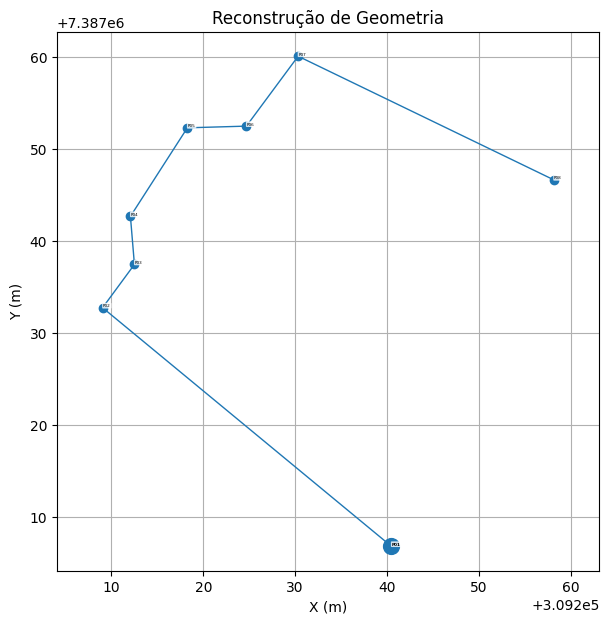

In [ ]:
# PLOTAGEM OS RESULTADOS SEM MAPA BASE

plt.figure(figsize=(7,7))
plt.plot(xv, yv, marker="o", linewidth=1)

texts = []

for i, (x, y) in enumerate(coords):
    label = f"P{i+1:02d}"

    if i == 0:
        plt.scatter(x, y, s=130, zorder=5)
        weight = "bold"
    else:
        weight = "normal"

    txt = plt.text(
        x, y, label,
        fontsize=3,
        fontweight=weight,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
        zorder=6
    )
    texts.append(txt)

# Ajuste automático (repulsão)
adjust_text(
    texts,
    x=xv,
    y=yv,
    expand_points=(1.5, 1.5),
    expand_text=(1.4, 1.4),
    force_points=0.4,
    force_text=0.8,
    arrowprops=dict(arrowstyle="-", lw=0.5)
)

plt.axis("equal")
plt.grid(True)
plt.title("Reconstrução de Geometria")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()


In [ ]:
# CÁLCULO DE ÁREA PELO MÉTODO ANALÍTICO DE GAUSS
coords_array = np.array(coords)

x = coords_array[:, 0]
y = coords_array[:, 1]

area_m2 = 0.5 * abs(
    np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
)

area_ha = area_m2 / 10_000

print(f"Área (Shoelace): {area_m2:,.2f} m² ({area_ha:.4f} ha)")


ValueError: data type must provide an itemsize

In [ ]:
# PLOTAGEM COM MAPA BASE
m = plot_vertices_folium(coords)
m

In [ ]:
import simplekml
from pyproj import Transformer

# EXPORTAÇÃO DA GEOMETRIA

# Transformação: SIRGAS2000 / UTM 23S -> WGS84
transformer = Transformer.from_crs(
    "EPSG:31983",  # SIRGAS2000 / UTM 23S
    "EPSG:4326",   # WGS84 (obrigatório para KML)
    always_xy=True
)

coords_geo = [transformer.transform(x, y) for x, y in coords]

kml = simplekml.Kml()

# Documento com descrição técnica
kml.document.name = "Vértices – Memorial Descritivo"
kml.document.description = (
    "Geometria originalmente calculada em:\n"
    "SIRGAS 2000 / UTM Zona 23S (EPSG:31983)\n\n"
    "Conversão para WGS84 (EPSG:4326) realizada "
    "exclusivamente para compatibilidade com o formato KML."
)

for i, ((x, y), (lon, lat)) in enumerate(zip(coords, coords_geo)):
    nome = f"P{i+1:02d}"

    pnt = kml.newpoint(
        name=nome,
        coords=[(lon, lat)]
    )

    pnt.description = (
        f"Vértice {nome}\n\n"
        f"SIRGAS2000 / UTM 23S:\n"
        f"X = {x:.3f} m\n"
        f"Y = {y:.3f} m\n\n"
        f"WGS84 (KML):\n"
        f"Lon = {lon:.8f}\n"
        f"Lat = {lat:.8f}"
    )

    pnt.style.iconstyle.scale = 0.9
    pnt.style.iconstyle.icon.href = (
        "http://maps.google.com/mapfiles/kml/shapes/placemark_circle.png"
    )

output_kml = "/content/vertices_sirgas2000_utm23S.kml"
kml.save(output_kml)

output_kml


'/content/vertices_sirgas2000_utm23S.kml'

3. GERAÇÃO DE MAPAS

In [ ]:
!pip install geopandas matplotlib contextily shapely matplotlib-scalebar cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 72.8 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar # Importação da barra de escala

def gerar_mapa_profissional(data_coords, crs, nome_imovel):
    # --- 1. CONFIGURAÇÃO DOS DADOS ---
    gdf = gpd.GeoDataFrame(index=[0], crs=crs, geometry=[Polygon(data_coords)])

    # --- 2. CRIAÇÃO DA FIGURA ---
    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.2], wspace=0.05)

    ax_mapa = fig.add_subplot(gs[0])
    ax_info = fig.add_subplot(gs[1])
    ax_info.axis('off')

    # --- 3. DESENHO DO MAPA ---
    gdf.plot(ax=ax_mapa, facecolor='none', edgecolor='yellow', linewidth=2, zorder=10)


    ctx.add_basemap(ax_mapa, source=ctx.providers.Esri.WorldImagery, crs=gdf.crs)
    ctx.add_basemap(ax_mapa, source=ctx.providers.CartoDB.PositronOnlyLabels, crs=gdf.crs, zorder=11)

    # --- 4. INSERÇÃO DO NORTE ---
    # Colocamos o Norte no canto superior direito do mapa
    x_n, y_n, largura_n = 0.95, 0.95, 0.03
    ax_mapa.annotate('N', xy=(x_n, y_n), xytext=(x_n, y_n-0.08),
                     arrowprops=dict(facecolor='white', width=4, headwidth=12),
                     ha='center', va='center', fontsize=20, color='white',
                     fontweight='bold', xycoords='axes fraction')

    # --- 5. INSERÇÃO DA BARRA DE ESCALA ---
    # Como o CRS é UTM (metros), a escala 1:1 funciona perfeitamente
    scalebar = ScaleBar(1, units="m", location="lower left",
                        box_alpha=0.5, color="white", frameon=False)
    ax_mapa.add_artist(scalebar)

    # --- 6. CONFIGURAÇÕES ESTÉTICAS ---
    ax_mapa.grid(True, linestyle='--', alpha=0.3, color='white')
    ax_mapa.set_title(f"Mapa de Localização - {nome_imovel}", fontsize=12, fontweight='bold', pad=10)

    # --- 7. QUADRO DE INFORMAÇÕES (SIDEBAR) ---
    texto_tecnico = (
        f"QUADRO DE INFORMAÇÕES\n"
        f"{'-'*25}\n"
        f"IMÓVEL:\n{nome_imovel}\n\n"
        f"LOCALIZAÇÃO:\nCotia - SP\n\n"
        f"SGR:\n{crs}\n\n"
        f"IMAGEM BASE:\nEsri/DigitalGlobe\n"
        f"Mosaico: v.2024\n\n"
        f"NOTAS:\nPerímetro via OCR\nMultimodal."
    )

    ax_info.text(0.0, 0.95, texto_tecnico, transform=ax_info.transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 linespacing=1.5,
                 bbox=dict(facecolor='#f8f8f8', alpha=0.95, edgecolor='black', boxstyle='round,pad=0.8'))

    # Finalização
    plt.tight_layout()
    plt.savefig("mapa_com_escala_e_norte.pdf", dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_15635/2964046536.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


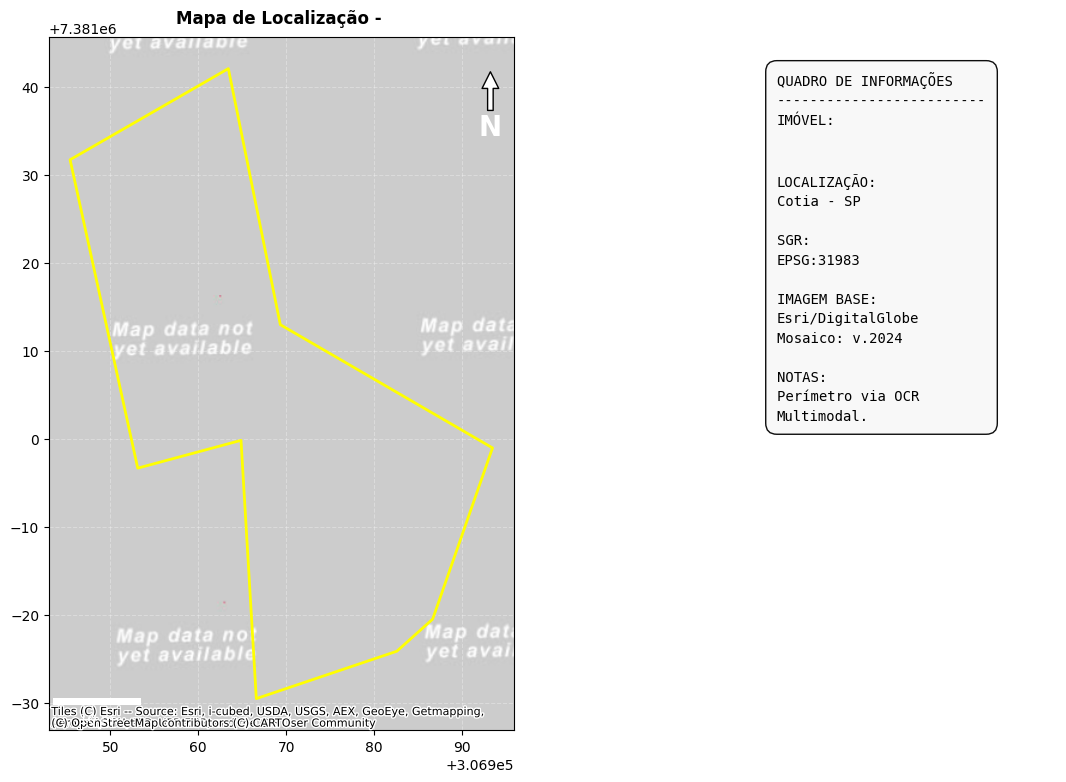

In [ ]:
gerar_mapa_profissional(coords, "EPSG:31983", "")
